- Complete evaluation pipeline
    - Input instance_id
    - get what test are failing before

- Docker understanding
    - flow in openhands
    - dockerfile

In [1]:
import json, os, random, math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
base_dir = "/workspaces/OpenHands/evaluation/evaluation_outputs/outputs/princeton-nlp__SWE-bench-dev/CodeActAgent"
run_name = "qwen-coder-30b-small_maxiter_100_N_176_baseline_logprobs"
all_instance_ids = [d for d in os.listdir(os.path.join(base_dir, run_name, "llm_completions")) if os.path.isdir(os.path.join(base_dir, run_name, "llm_completions", d))]

# LogProbs Analysis
- First categorize samples to succeed, failed, partially failed
    - For failed, first focus on those reach max iterations
- Pick a max-iter-failed example, plot histogram on log prob
- 

In [49]:
def get_logprobs_from_turn(turn):
    try:
        return turn["tool_call_metadata"]["model_response"]["choices"][0]["logprobs"]
    except:
        return None


def is_structural(tok):
    return tok in ("<tool_call>", "</tool_call>", "\n") or tok.startswith("<")


def turn_logprob(logprob_list, token_list):
    seq_logprob = 0.0
    valid_logprob_count = 0
    for token, logprob in zip(token_list, logprob_list):
        if is_structural(token):
            continue
        if logprob is not None:
            seq_logprob += logprob
            valid_logprob_count += 1
    seq_prob = math.exp(seq_logprob)
    avg_logprob = seq_logprob / valid_logprob_count

    return {
        "sequence_log_probs": seq_logprob,
        "avergage_logprob_per_token": avg_logprob,
        "sequence_prob": seq_prob,
    }

def trajectory_logprob_stats(trajectory):
    logprob_infos = []

    for turn in trajectory:
        logprob_dict = get_logprobs_from_turn(turn)
        if not logprob_dict:
            continue
        token_list = logprob_dict["tokens"]
        logprob_list = logprob_dict["all_logprobs"]

        sequence_logprob_info = turn_logprob(logprob_list, token_list)
        logprob_infos.append(sequence_logprob_info)
    return logprob_infos


def plot_trajectory_logprob_hists(trajectory):
    seq_logprobs = []
    avg_logprobs = []
    seq_probs = []

    for turn in trajectory:
        logprob_dict = get_logprobs_from_turn(turn)
        if not logprob_dict:
            continue

        # your saved names:
        token_list = logprob_dict["tokens"]
        logprob_list = logprob_dict["all_logprobs"]

        turn_stats = turn_logprob(logprob_list, token_list)
        seq_logprobs.append(turn_stats["sequence_log_probs"])
        avg_logprobs.append(turn_stats["avergage_logprob_per_token"])
        seq_probs.append(turn_stats["sequence_prob"])

    # guard: if nothing to plot
    if not seq_logprobs:
        print("No logprob data found in trajectory.")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1) sequence_log_probs
    axes[0].hist(seq_logprobs, bins=20)
    axes[0].set_title("Sequence log probs")
    axes[0].set_xlabel("log P(sequence)")
    axes[0].set_ylabel("count")

    # 2) average_logprob_per_token
    axes[1].hist(avg_logprobs, bins=20)
    axes[1].set_title("Avg log prob per token")
    axes[1].set_xlabel("avg log p")
    axes[1].set_ylabel("count")

    # 3) sequence_prob
    axes[2].hist(seq_probs, bins=20)
    axes[2].set_title("Sequence prob")
    axes[2].set_xlabel("P(sequence)")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()


def get_trajectory_from_instance_id(instance_id, base_dir, run_name):
    trajectory_file = os.path.join(
        base_dir,
        run_name,
        "llm_completions",
        instance_id,
        f"{instance_id}_trajectory.json"
    )

    with open(trajectory_file, "r") as f:
        trajectory = json.load(f)
    return trajectory


def turn_to_turn_logprob_dynamics(logprob_infos):
    # logprob_infos: list of dicts from your trajectory_logprob_stats
    seq_logprobs = [d["sequence_log_probs"] for d in logprob_infos]
    deltas = [seq_logprobs[i] - seq_logprobs[i-1] for i in range(1, len(seq_logprobs))]
    return seq_logprobs, deltas


def plot_turn_dynamics(logprob_infos, status, instance_id):
    seq_logprobs, deltas = turn_to_turn_logprob_dynamics(logprob_infos)

    plt.figure(figsize=(8, 4))
    plt.plot(range(len(seq_logprobs)), seq_logprobs, marker='o', label='Sequence logprob')
    plt.plot(range(1, len(seq_logprobs)), deltas, marker='x', linestyle='--', label='Δ logprob (turn-to-turn)')
    plt.xlabel("Turn index")
    plt.ylabel("logprob")
    plt.title(f"{instance_id} Turn-to-turn logprob dynamics: {status}")
    plt.legend()
    plt.grid(True)
    plt.show()





In [34]:
# Find partially resolved instances

eval_log_folder = "/workspaces/OpenHands/evaluation/evaluation_outputs/outputs/princeton-nlp__SWE-bench-dev/CodeActAgent/qwen-coder-30b-small_maxiter_100_N_176_baseline_logprobs/final_eval/logs/run_evaluation/llm.qwen_coder_30b_small/qwen-coder-30b-small_maxiter_100_N_176_baseline_logprobs_2"

fully_resolved = []
partial_resolve_no_degrad = []
partial_resolve_degrad = []
fully_fail = []

for instance_id in all_instance_ids:
    report_json = os.path.join(
        eval_log_folder,
        instance_id,
        "report.json"
    )
    try:
        with open(report_json, "r") as f:
            report = json.load(f)[instance_id]
    except:
        print("Not found for instance", instance_id)
        continue

    test_status = report["tests_status"]

    # Case 1: fully resolve
    if report["resolved"]:
        fully_resolved.append(instance_id)
        continue
    # Case 2: partially resolve and no degradation
    if len(test_status["FAIL_TO_PASS"]["success"]) > 0 and \
        len(test_status["FAIL_TO_PASS"]["failure"]) > 0 and \
        len(test_status["PASS_TO_PASS"]["failure"]) == 0:
        partial_resolve_no_degrad.append(instance_id)
        continue
    # Case 3: partially resolve but degradation
    if len(test_status["FAIL_TO_PASS"]["success"]) > 0 and \
        len(test_status["PASS_TO_PASS"]["failure"]) > 0:
        partial_resolve_degrad.append(instance_id)
        continue
    # Case 4: completely fail
    if len(test_status["FAIL_TO_PASS"]["success"]) == 0:
        fully_fail.append(instance_id)
        continue


Not found for instance pydicom__pydicom-1255


In [21]:
fully_resolved

['pvlib__pvlib-python-1349',
 'marshmallow-code__marshmallow-1252',
 'pydicom__pydicom-938',
 'pylint-dev__astroid-1903',
 'pvlib__pvlib-python-1606',
 'pylint-dev__astroid-1719',
 'pydicom__pydicom-1228',
 'pylint-dev__astroid-1616',
 'sqlfluff__sqlfluff-880',
 'pydicom__pydicom-800',
 'marshmallow-code__marshmallow-1810',
 'pydicom__pydicom-1192',
 'pydicom__pydicom-1694',
 'pydicom__pydicom-1256',
 'marshmallow-code__marshmallow-1164',
 'pylint-dev__astroid-1614',
 'pvlib__pvlib-python-1738',
 'sqlfluff__sqlfluff-2419',
 'marshmallow-code__marshmallow-1343']

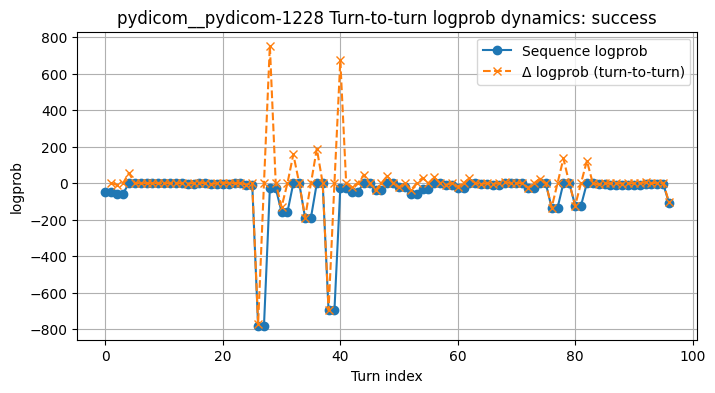

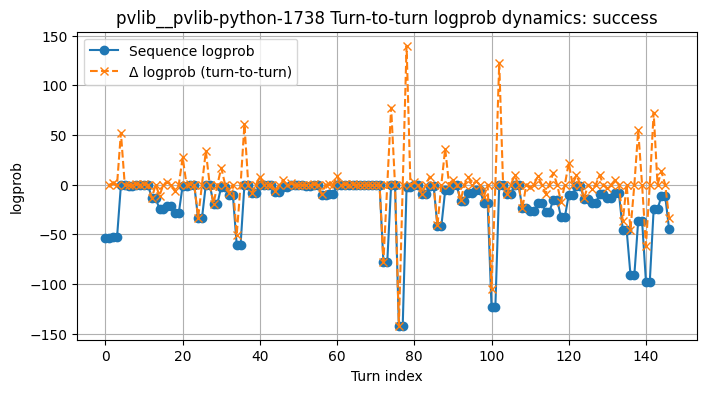

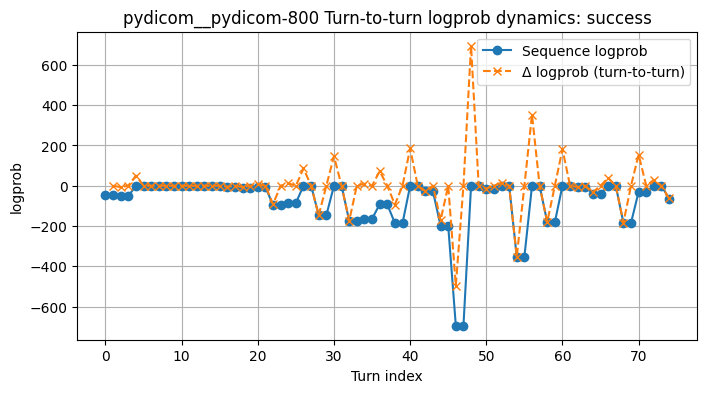

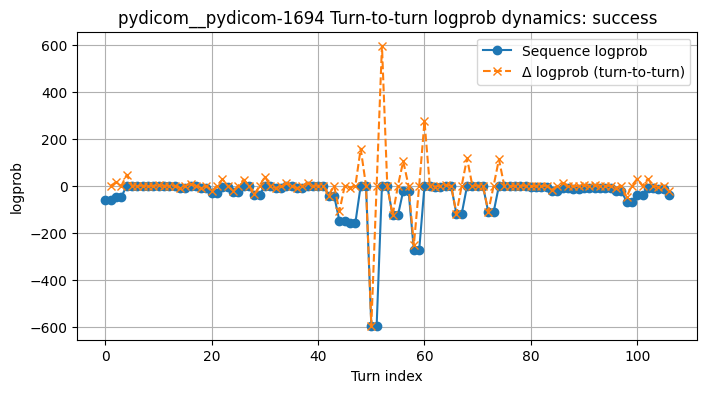

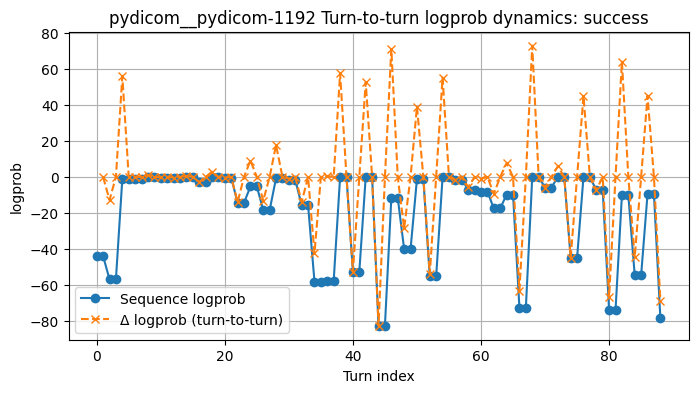

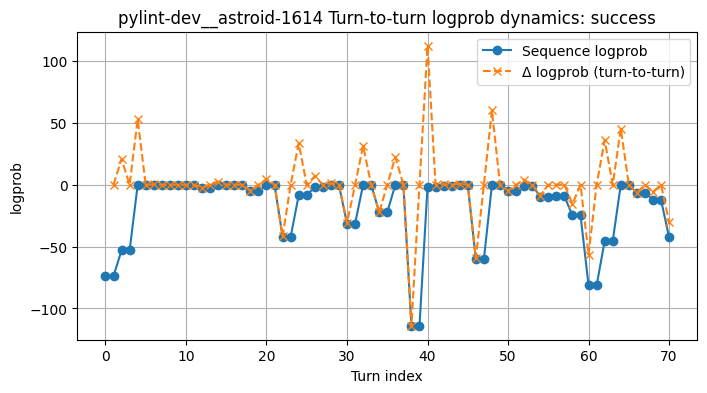

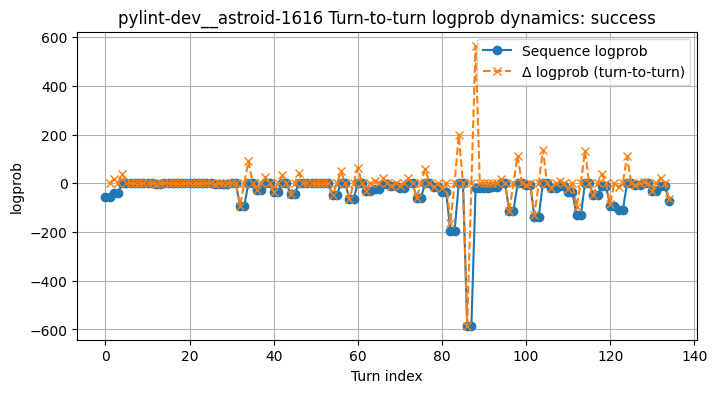

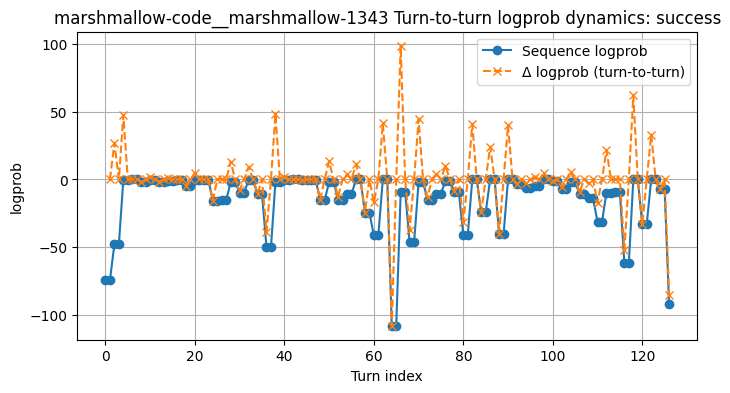

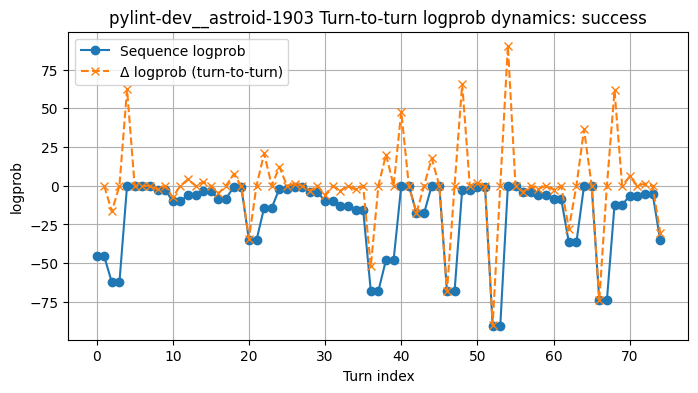

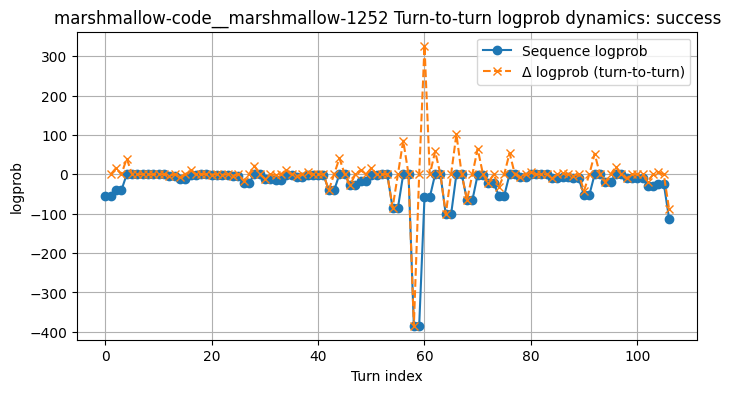

In [63]:

for instance_id in random.sample(fully_resolved, 10):
    trajectory = get_trajectory_from_instance_id(instance_id,
                                                base_dir,
                                                run_name)

    plot_turn_dynamics(
        logprob_infos=trajectory_logprob_stats(trajectory), status="success", instance_id=instance_id,
    )

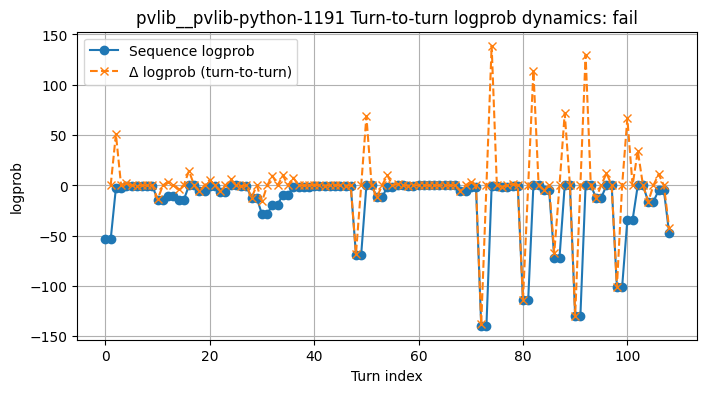

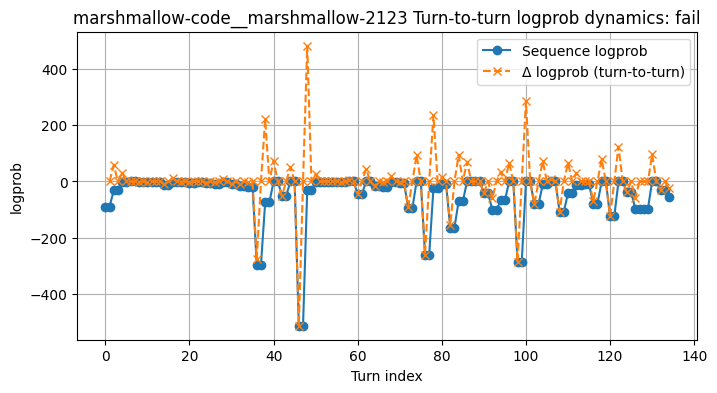

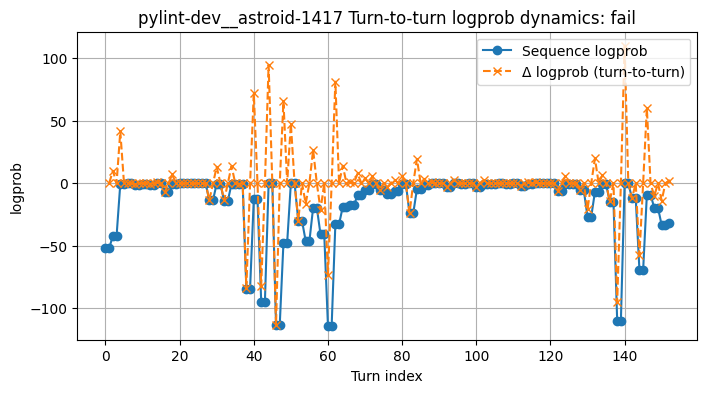

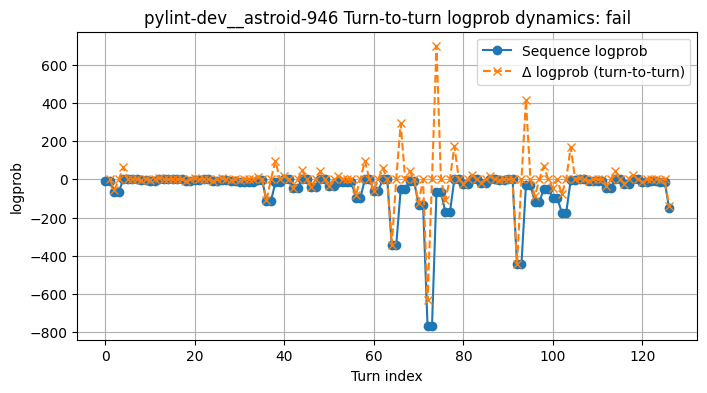

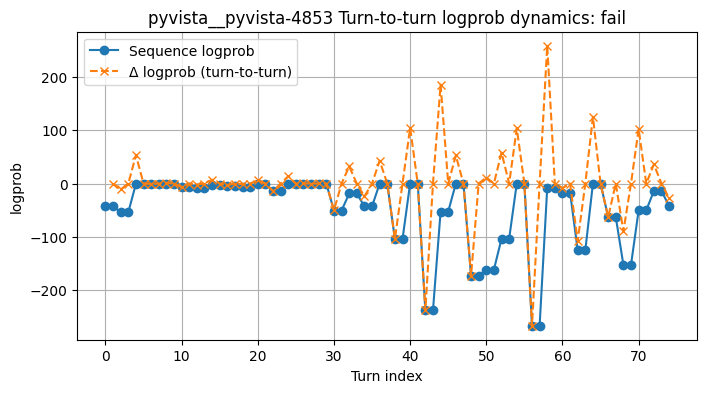

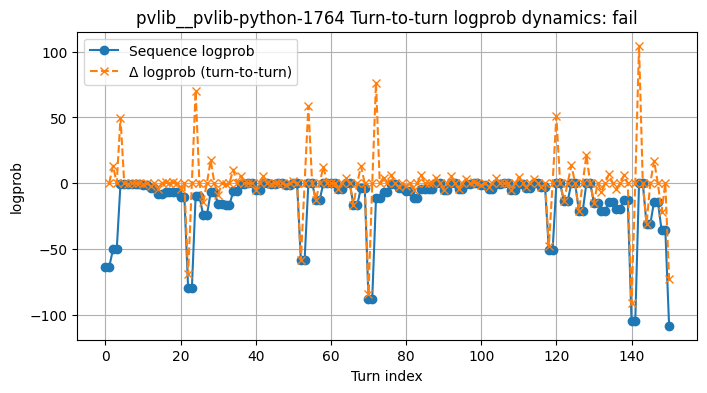

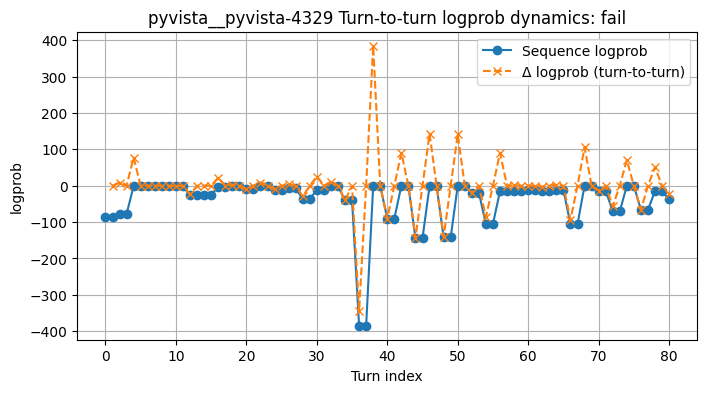

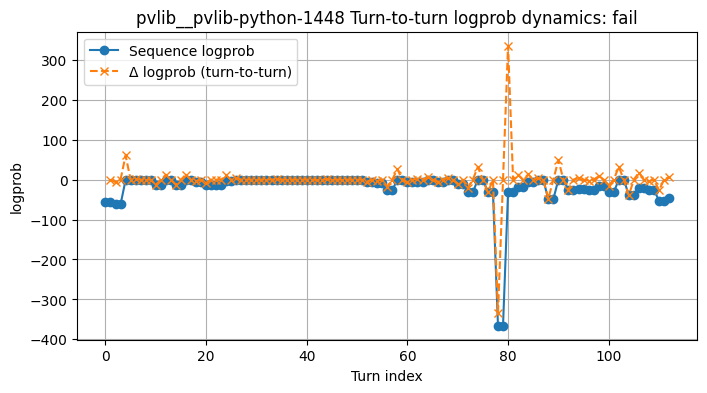

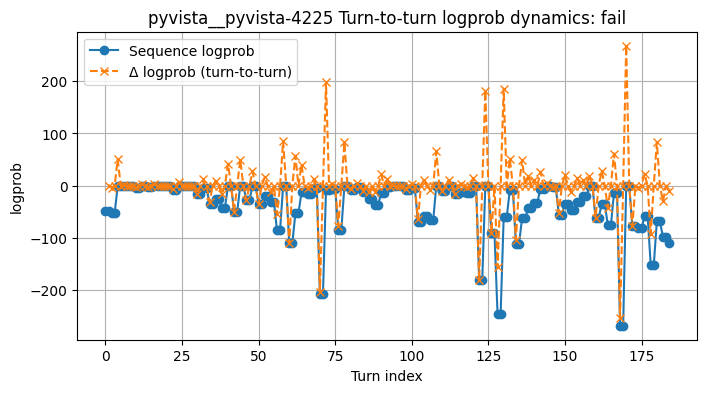

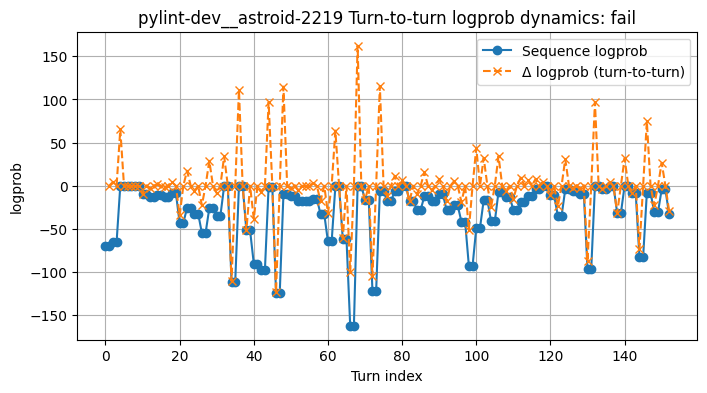

In [62]:

for instance_id in random.sample(fully_fail, 10):
    trajectory = get_trajectory_from_instance_id(instance_id,
                                                base_dir,
                                                run_name)

    plot_turn_dynamics(
        logprob_infos=trajectory_logprob_stats(trajectory), status="fail", instance_id=instance_id,
    )

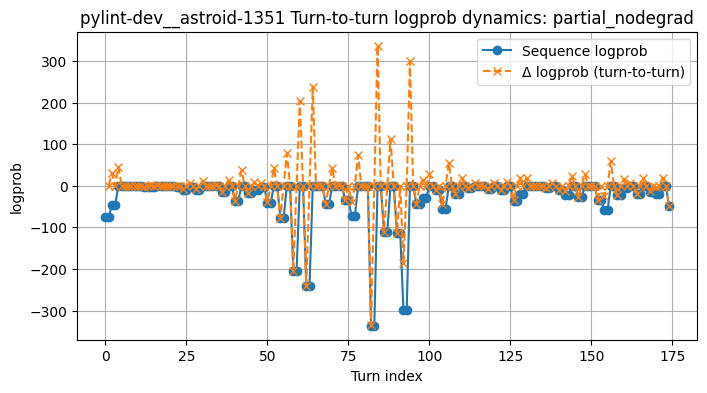

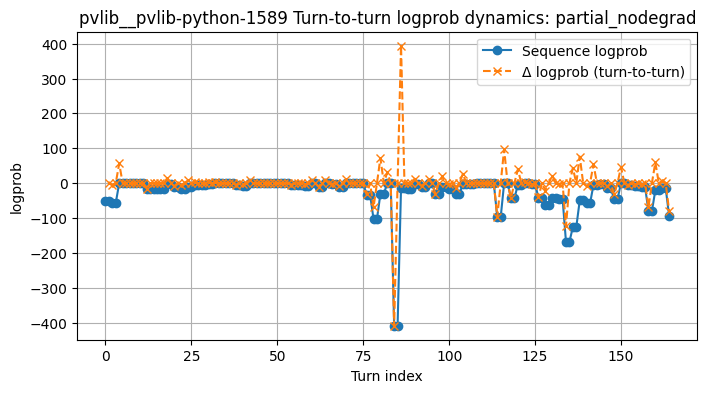

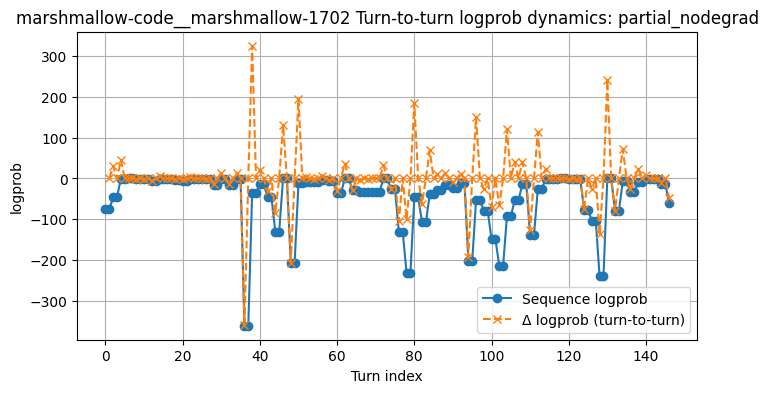

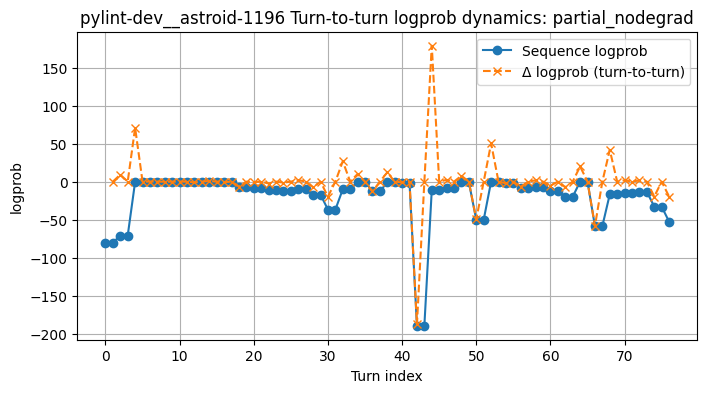

In [ ]:

for instance_id in random.sample(partial_resolve_no_degrad, 4):
    trajectory = get_trajectory_from_instance_id(instance_id,
                                                base_dir,
                                                run_name)

    plot_turn_dynamics(
        logprob_infos=trajectory_logprob_stats(trajectory), status="partial_nodegrad", instance_id=instance_id,
    )

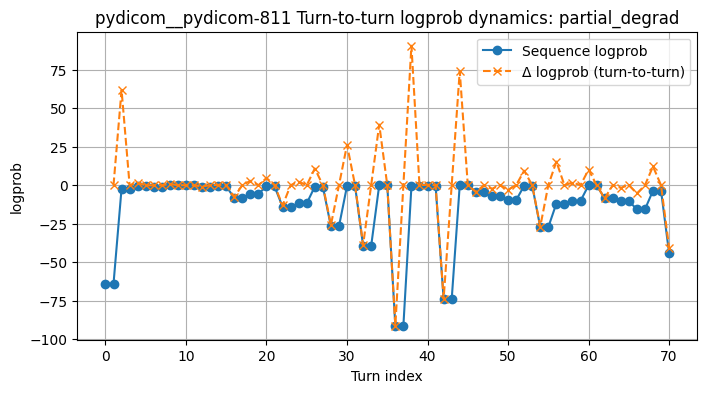

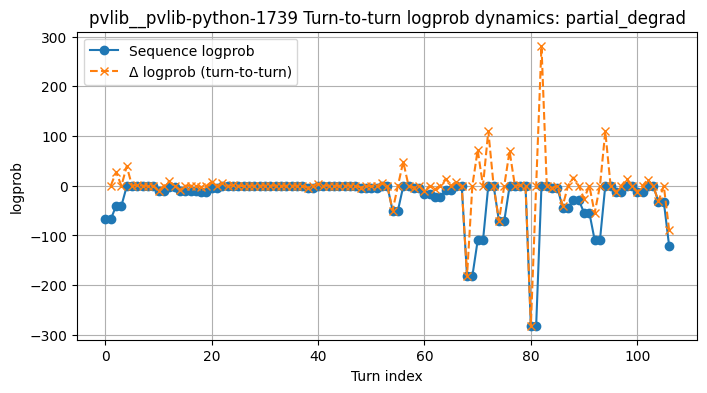

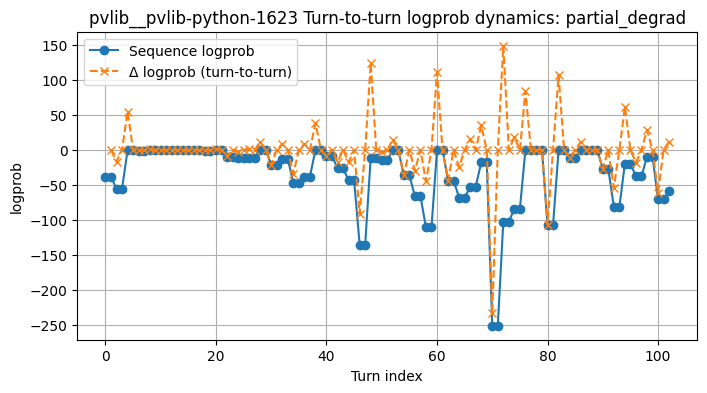

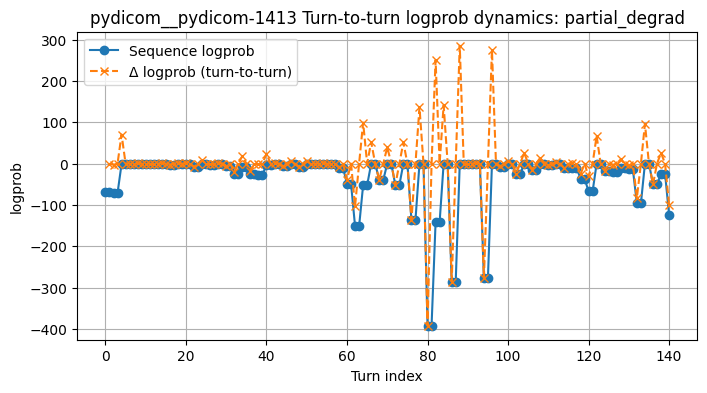

In [ ]:

for instance_id in random.sample(partial_resolve_degrad, 4):
    trajectory = get_trajectory_from_instance_id(instance_id,
                                                base_dir,
                                                run_name)

    plot_turn_dynamics(
        logprob_infos=trajectory_logprob_stats(trajectory), status="partial_degrad", instance_id=instance_id,
    )

In [ ]:
# fully resolve
# fully fail
# partial nodegrad:
# partial degrad



# no degrad
# ['pvlib__pvlib-python-1589',
#  'pylint-dev__astroid-1351',
#  'pylint-dev__astroid-984',
#  'marshmallow-code__marshmallow-1702',
#  'marshmallow-code__marshmallow-1524',
#  'pylint-dev__astroid-1196']

# with degrad
# ['pydicom__pydicom-1413',
#  'pydicom__pydicom-1539',
#  'pydicom__pydicom-1069',
#  'pydicom__pydicom-1194',
#  'pydicom__pydicom-1365',
#  'pydicom__pydicom-1139',
#  'pydicom__pydicom-933',
#  'pydicom__pydicom-1416',
#  'pylint-dev__astroid-941',
#  'pvlib__pvlib-python-1739',
#  'pydicom__pydicom-1555',
#  'pydicom__pydicom-1375',
#  'pydicom__pydicom-1076',
#  'pvlib__pvlib-python-1623',
#  'pydicom__pydicom-811']

In [51]:
fully_resolve_instance = "pvlib__pvlib-python-1349"
partial_no_degrad_instance = "pvlib__pvlib-python-1589"
partial_degrad_instance = "pvlib__pvlib-python-1739"
fully_fail_instance = "pvlib__pvlib-python-1395"

# fully_resolve_instance = "pylint-dev__astroid-1903"
# partial_no_degrad_instance = "pylint-dev__astroid-1196"
# partial_degrad_instance = "pylint-dev__astroid-941"
# fully_fail_instance = "pylint-dev__astroid-1364"

In [58]:
# for idx, instance_id in enumerate([
#     fully_resolve_instance,
#     partial_no_degrad_instance,
#     partial_degrad_instance,
#     fully_fail_instance
# ]):
#     trajectory = get_trajectory_from_instance_id(instance_id,
#                                                 base_dir,
#                                                 run_name)
#     if idx == 0:
#         status = "success"
#     elif idx == 1:
#         status = "partial_no_degrad"
#     elif idx == 2:
#         status = "partial_degrad"
#     else:
#         status = "fail"

#     plot_turn_dynamics(
#         logprob_infos=trajectory_logprob_stats(trajectory), status=status, instance_id=instance_id,
#     )

In [46]:
# mean, bottom 5p
# confidence

# Self-reflection Analysis
- For each problem, how many turns does self-reflection get triggered?

In [ ]:
base_dir = "/workspaces/OpenHands/evaluation/evaluation_outputs/outputs/princeton-nlp__SWE-bench-dev/CodeActAgent"
# run_name = "qwen-coder-30b-small_maxiter_100_N_176_reflection_1030"
# run_name = "qwen-coder-30b-small_maxiter_100_N_176_baseline"
run_name = "qwen-coder-30b-small_maxiter_100_N_176_reflection_no_prob"




instance_ids = [d for d in os.listdir(os.path.join(base_dir, run_name, "llm_completions")) if os.path.isdir(os.path.join(base_dir, run_name, "llm_completions", d))]
# instance_id = random.sample(instance_ids, 1)[0]
# print('Instance ID', instance_id)

total_actions_list = []
reflection_actions_list = []

for instance_id in instance_ids:
    trajectory_file = os.path.join(
        base_dir,
        run_name,
        "llm_completions",
        instance_id,
        f"{instance_id}_trajectory.json"
    )

    with open(trajectory_file, "r") as f:
        trajectory = json.load(f)


    total_actions, reflection_actions = 0, 0
    for turn in trajectory:
        if not turn.get("action", None):
            continue
        total_actions += 1
        meta = turn.get("tool_call_metadata", {})
        if meta.get("function_name") == "reflection":
            reflection_actions += 1
        if "[AutoReflect]" in turn.get("message", None):
            reflection_actions += 1

    total_actions_list.append(total_actions)
    reflection_actions_list.append(reflection_actions)
